# Astronomy CNN with PyTorch

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

First, we load the data and print the shapes.

In [2]:
spectra = np.load(f"../datasets/spectra.npy")
spectra_length = spectra.shape[1]

# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
units = ["M_sun", "Gyr", "L_sun", "pc", "K", "", "", ""]
labels = np.load(f"../datasets/labels.npy")

# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
units = units[-4:-1]
n_labels = labels.shape[1]
n_samples = spectra.shape[0]

In [3]:
print("spectra shape:", spectra.shape)
print("labels shape:", labels.shape)
print("label names:", labelNames)

spectra shape: (8914, 16384)
labels shape: (8914, 3)
label names: ['t_eff', 'log_g', 'fe_h']


In [4]:
print("spectra length:", spectra_length)
print("number of samples:", n_samples)
print("number of labels:", n_labels)

spectra length: 16384
number of samples: 8914
number of labels: 3


Now, we normalize the spectra.

In [5]:
# normalize the spectra
spectra_scaled = np.log(np.maximum(spectra, 0.2))

And we plot the spectra of some of the stars. The wavelenght ranges from $4718\text{ \AA}$ to $7890\text{ \AA}$.

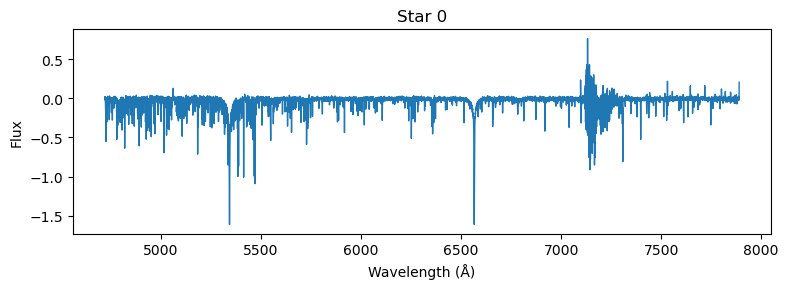

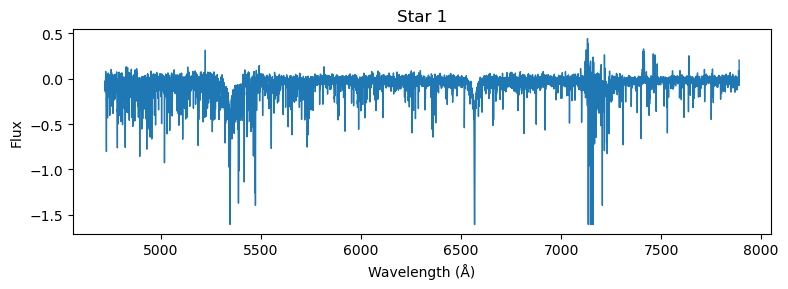

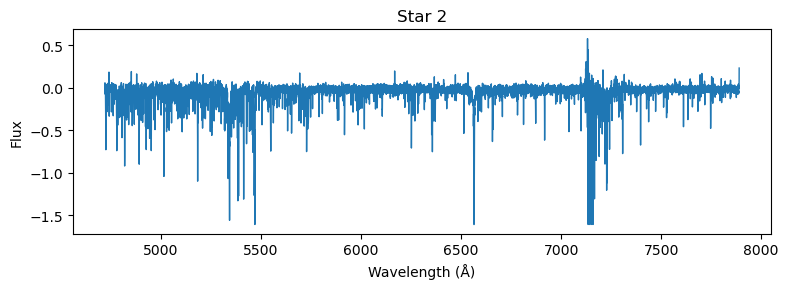

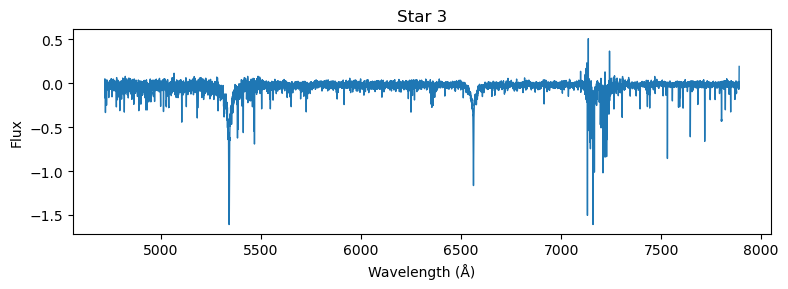

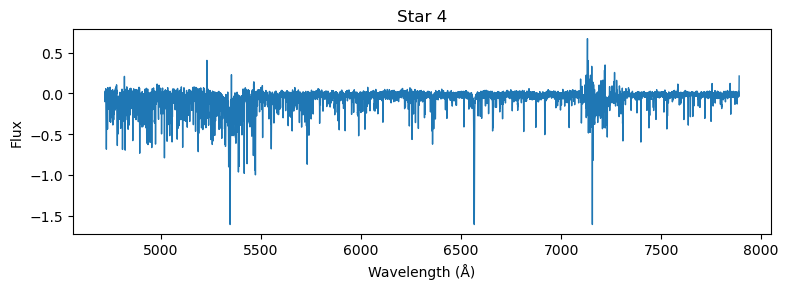

In [6]:
# plot a few spectra
wavelenghts = np.linspace(4718, 7890, spectra_length) # from the dataset description
for i in range(5):
  fig, ax = plt.subplots(1, 1, figsize=(8, 3))
  ax.plot(wavelenghts, spectra_scaled[i], lw=1)
  ax.set_title(f"Star {i}")
  ax.set_xlabel("Wavelength (Å)")
  ax.set_ylabel("Flux")
  plt.tight_layout()

We select the device that will be used for training.

In [7]:
# Check for available devices and select if available
device = (
    "cuda"
    if torch.cuda.is_available()  # CUDA GPU
    else "mps"
    if torch.backends.mps.is_available()  # Apple Metal Performance Shaders
    else "xpu"
    if torch.xpu.is_available()  # Intel XPU
    else "cpu"  # Fallback to CPU if neither CUDA nor MPS are found
)
print(f"Using device: {device}")

Using device: xpu


In [8]:
# Split data into train, validation, and test sets
test_fraction = 0.15
val_fraction = 0.15
r1 = test_fraction + val_fraction
r2 = val_fraction / r1

X_train, X_temp, labels_train, labels_temp = train_test_split(spectra_scaled, labels, test_size=r1, random_state=25)
X_val, X_test, labels_val, labels_test = train_test_split(X_temp, labels_temp, test_size=r2, random_state=37)

In [9]:
# Normalize the labels using only the training set statistics
scaler = StandardScaler()
y_train = scaler.fit_transform(labels_train)
y_val = scaler.transform(labels_val)
y_test = scaler.transform(labels_test)

In [10]:
# Define a custom Dataset class
class CustomDataset(TensorDataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets with torch tensors
train_dataset = CustomDataset(torch.as_tensor(X_train, dtype=torch.float32).view(-1, 1, spectra_length),
                              torch.as_tensor(y_train, dtype=torch.float32).view(-1, n_labels))
val_dataset = CustomDataset(torch.as_tensor(X_val, dtype=torch.float32).view(-1, 1, spectra_length),
                            torch.as_tensor(y_val, dtype=torch.float32).view(-1, n_labels))
test_dataset = CustomDataset(torch.as_tensor(X_test, dtype=torch.float32).view(-1, 1, spectra_length),
                             torch.as_tensor(y_test, dtype=torch.float32).view(-1, n_labels))

In [11]:
# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [12]:
class GalahCNN(nn.Module):
    def __init__(self):
        super(GalahCNN, self).__init__()
        
        # Feature extraction (3 convolutional layers)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Linear regression (2 fully connected layers)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spectra_length // 8, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Avoid overfitting
            nn.Linear(256, n_labels) # Output: Teff, logg, [Fe/H]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [13]:
# Initialize the model
model = GalahCNN().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
# Train the model
num_epochs = 20
train_losses, val_losses = [], []

for epoch in range(num_epochs):  # loop through every epoch
    # Training
    model.train()  # The model should be in training mode to use batch normalization and dropout
    train_loss = 0

    # loop through every batch
    for batch_x, batch_y in train_loader:
        # move the batch to the same device as the model
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # set the gradients to zero
        optimizer.zero_grad()

        # make a prediction with the current model
        predictions = model(batch_x)

        # calculate the loss based on the prediction
        loss = loss_fn(predictions, batch_y)

        # calculated the gradiets for the given loss
        loss.backward()

        # updates the weights and biases for the given gradients
        optimizer.step()

        # calulate loss per batch
        train_loss += loss.item()

    # calulate loss per epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    # The model should be in eval mode to not use batch normalization and dropout
    model.eval()
    val_loss = 0

    # make sure the gradients are not changed in this step
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # move the batch to the same device as the model
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # make a prediction with the current model
            predictions = model(batch_x)

            # calculate the loss based on the prediction
            loss = loss_fn(predictions, batch_y)

            # calculate loss per batch
            val_loss += loss.item()

    # calulate loss per epoch
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Print progress
    if epoch % 2 == 0:
        print(
            f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}"
        )


Epoch 0: Train Loss = 0.6944, Val Loss = 0.3992
Epoch 2: Train Loss = 0.1315, Val Loss = 0.0781
Epoch 4: Train Loss = 0.0808, Val Loss = 0.0527
Epoch 6: Train Loss = 0.0666, Val Loss = 0.0469
Epoch 8: Train Loss = 0.0592, Val Loss = 0.0424
Epoch 10: Train Loss = 0.0546, Val Loss = 0.0443
Epoch 12: Train Loss = 0.0508, Val Loss = 0.0396
Epoch 14: Train Loss = 0.0479, Val Loss = 0.0391
Epoch 16: Train Loss = 0.0473, Val Loss = 0.0352
Epoch 18: Train Loss = 0.0453, Val Loss = 0.0423


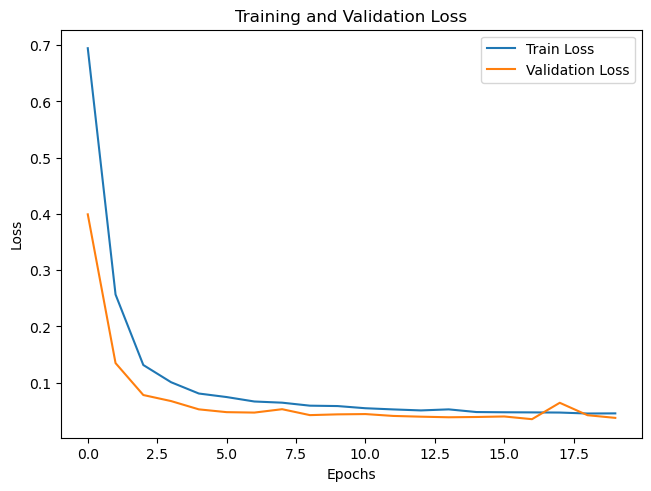

In [15]:
# Plot training/validation loss
fig, ax = plt.subplots(layout="constrained")

ax.plot(train_losses, label="Train Loss")
ax.plot(val_losses, label="Validation Loss")

ax.legend()
ax.set(
    xlabel="Epochs",
    ylabel="Loss",
    title="Training and Validation Loss",
);

In [16]:
# Test the model
model.eval()
test_loss = 0
y_test_pred = np.array([])

# make sure the gradients are not changed in this step
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # move the batch to the same device as the model
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # make a prediction with the current model
        predictions = model(batch_x)
        y_test_pred = np.append(y_test_pred, predictions.cpu().numpy())

        # calculate the loss based on the prediction
        loss = loss_fn(predictions, batch_y)

        # calulate loss per batch
        test_loss += loss.item()

test_loss /= len(test_loader)  # calculate total loss
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Loss: 0.0405


In [17]:
y_test_pred = y_test_pred.reshape(-1, n_labels)
labels_test_pred = scaler.inverse_transform(y_test_pred)

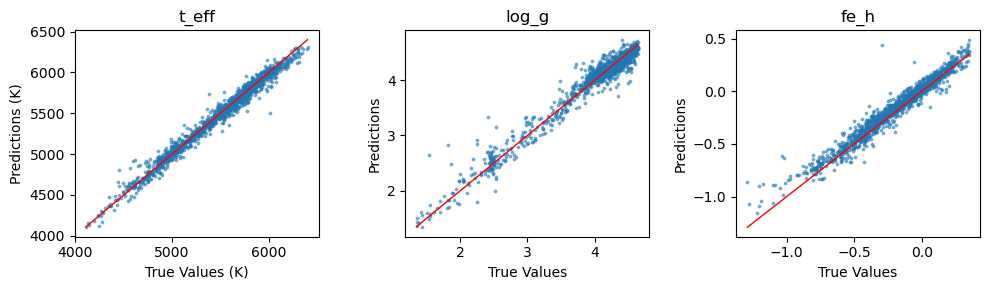

In [18]:
plt.figure(figsize=(10, 3))
for i in range(n_labels):
    plt.subplot(1, n_labels, i+1)
    plt.plot([labels_test[:, i].min(), labels_test[:, i].max()], 
             [labels_test[:, i].min(), labels_test[:, i].max()], 'r', lw=1) # Add a y=x line for reference
    plt.scatter(labels_test[:, i], labels_test_pred[:, i], label=labels[i], alpha=0.5, s=3)
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    if units[i]:
        plt.xlabel(f"True Values ({units[i]})")
        plt.ylabel(f"Predictions ({units[i]})")
    plt.title(labelNames[i])
plt.tight_layout()
plt.show()

In [19]:
rms = np.sqrt(np.mean((labels_test - labels_test_pred) ** 2, axis=0))
for i in range(n_labels):
    print(f"RMS error for {labelNames[i]}: {rms[i]:.3g} {units[i]}")

RMS error for t_eff: 66.3 K
RMS error for log_g: 0.135 
RMS error for fe_h: 0.0721 


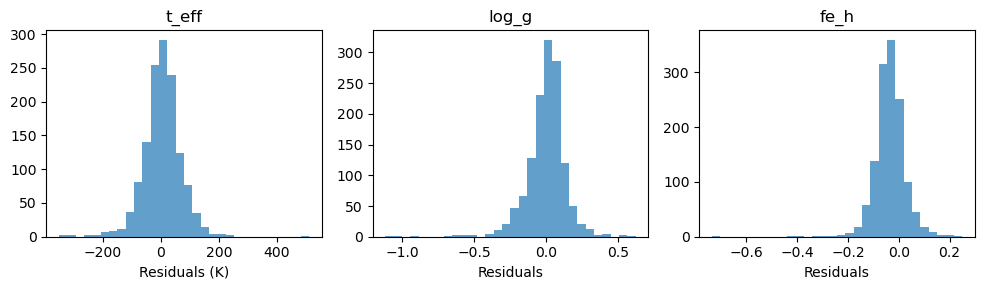

In [20]:
residuals = labels_test - labels_test_pred
plt.figure(figsize=(10, 3))
for i in range(n_labels):
    plt.subplot(1, n_labels, i+1)
    plt.hist(residuals[:, i], bins=30, alpha=0.7)
    plt.xlabel("Residuals")
    if units[i]:
        plt.xlabel(f"Residuals ({units[i]})")
    plt.title(labelNames[i])
plt.tight_layout()
plt.show()

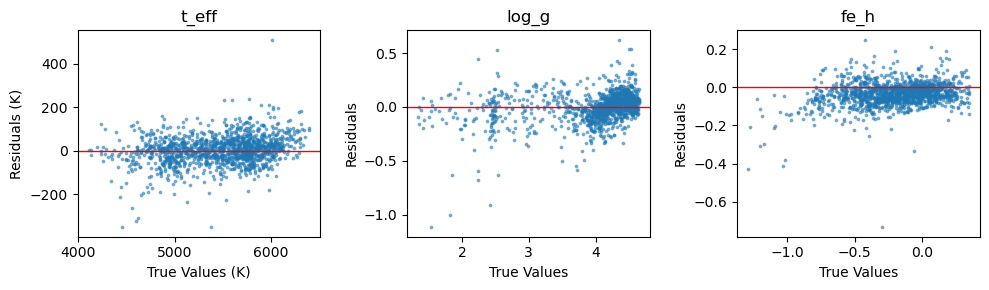

In [21]:
plt.figure(figsize=(10, 3))
for i in range(n_labels):
    plt.subplot(1, n_labels, i+1)
    plt.scatter(labels_test[:, i], residuals[:, i], label=labels[i], alpha=0.5, s=3)
    plt.axhline(0, color='r', lw=1) # Add a horizontal line at y=0 for reference
    plt.xlabel("True Values")
    plt.ylabel("Residuals")
    if units[i]:
        plt.xlabel(f"True Values ({units[i]})")
        plt.ylabel(f"Residuals ({units[i]})")
    plt.title(labelNames[i])
plt.tight_layout()
plt.show()

In [22]:
bias = np.mean(residuals, axis=0)
for i in range(n_labels):
    print(f"bias for {labelNames[i]}: {bias[i]:.3g} {units[i]}")

bias for t_eff: 3.88 K
bias for log_g: 0.00108 
bias for fe_h: -0.0358 
